# **Reduction**(Master Bias and Master Flats)

---



# Imports

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits
import os

# Create master bias

In [ ]:
bias_dir = "/content/sample_data/Bias/" # Folder with all the bias
bias_files = ["FORS2.2004-04-13T10_45_25.496.fits","FORS2.2004-04-13T10_45_56.028.fits","FORS2.2004-04-13T10_46_25.190.fits",
              "FORS2.2004-04-13T10_46_55.603.fits","FORS2.2004-04-13T10_47_26.784.fits"]

# Load the Bias Images
bias_images = []
for file in bias_files:
    image = fits.getdata(bias_dir+file)
    bias_images.append(image)

# Stack the Bias images using median
master_bias = np.median(np.asarray(bias_images), axis=0)


# Save the master bias as a FITS file(in the working directory)

In [ ]:
savename=bias_dir+"master_bias.fits"
fits.writeto(savename, master_bias, overwrite=True)

# Create Master Flat

In [ ]:
# Create master flat
flat_dir = "/content/sample_data/Flat/" # Folder with all the flats
flat_files = ["FORS2.2004-04-11T22_57_55.203.fits","FORS2.2004-04-11T22_58_31.835.fits","FORS2.2004-04-11T22_59_09.848.fits",
              "FORS2.2004-04-11T22_59_49.181.fits"]

# Load the Flat Images
flat_images = []
for file in flat_files:
    image = fits.getdata(flat_dir+file)
    flat_images.append(image)

# Stack the flat images

cflats = []
for ic in range(len(flat_images)):
    cflats.append((flat_images[ic] - master_bias)/np.median(flat_images[ic]-master_bias))
master_flat = np.median(cflats,axis=0)


# Save the master flat as a FITS file

In [ ]:
fits.writeto(flat_dir+"master_flat.fits", master_flat, overwrite=True)

# Plot both

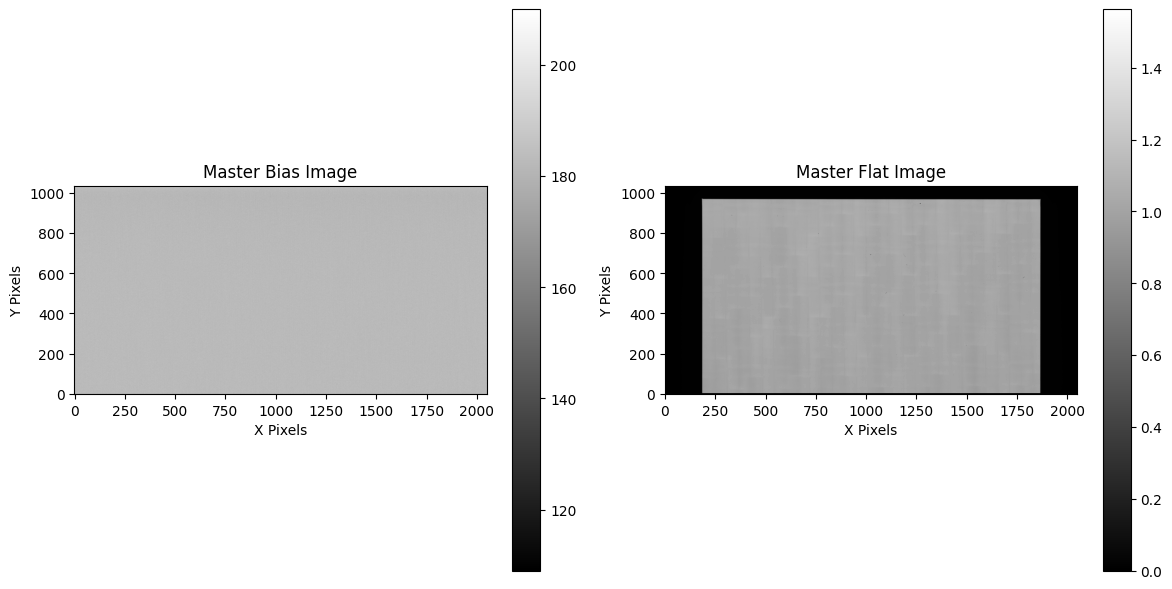

In [ ]:
# Create a single figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns of subplots

# Plot the master bias in the first subplot
im1 = ax1.imshow(master_bias, cmap='gray', origin='lower')
ax1.set_title('Master Bias Image')
ax1.set_xlabel('X Pixels')
ax1.set_ylabel('Y Pixels')
fig.colorbar(im1, ax=ax1)  # Use fig.colorbar with the corresponding axis

# Plot the master flat in the second subplot
im2 = ax2.imshow(master_flat, cmap='gray', origin='lower')
ax2.set_title('Master Flat Image')
ax2.set_xlabel('X Pixels')
ax2.set_ylabel('Y Pixels')
fig.colorbar(im2, ax=ax2)  # Use fig.colorbar with the corresponding axis

plt.tight_layout()  # Ensure proper spacing between subplots
plt.show()